In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("../macro_monthly_clean.csv", index_col=0)
df.index = pd.to_datetime(df.index)

df.head()

,cpi,unemployment,gdp,industrial_prod,fed_funds,personal_income,retail_sales,housing_starts,treasury_10y,treasury_2y
1954-07-31,26.86,5.8,390.996,18.0907,0.80,391.8,159177.0,1657.0,4.1,7.02
1954-10-31,26.72,5.7,399.734,18.3058,0.85,391.8,159177.0,1657.0,4.1,7.02
1955-01-31,26.77,4.9,413.073,19.2735,1.39,391.8,159177.0,1657.0,4.1,7.02
1955-04-30,26.79,4.7,421.532,20.2143,1.43,391.8,159177.0,1657.0,4.1,7.02
1955-07-31,26.76,4.0,430.221,20.7251,1.68,391.8,159177.0,1657.0,4.1,7.02


In [10]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.tail()

Shape: (818, 10)

Columns: ['cpi', 'unemployment', 'gdp', 'industrial_prod', 'fed_funds', 'personal_income', 'retail_sales', 'housing_starts', 'treasury_10y', 'treasury_2y']


,cpi,unemployment,gdp,industrial_prod,fed_funds,personal_income,retail_sales,housing_starts,treasury_10y,treasury_2y
2025-04-30,320.321,4.2,30485.729,103.6224,4.33,26111.5,721789.0,1398.0,4.17,3.60
2025-05-31,320.580,4.2,30485.729,103.6570,4.33,26011.2,716101.0,1282.0,4.41,3.89
2025-06-30,321.500,4.1,30485.729,104.2115,4.33,26078.6,723033.0,1382.0,4.24,3.72
2025-07-31,322.132,4.2,30485.729,103.8194,4.33,26184.2,727414.0,1429.0,4.37,3.94
2025-08-31,323.364,4.3,30485.729,103.9203,4.33,26279.9,732010.0,1307.0,4.23,3.59


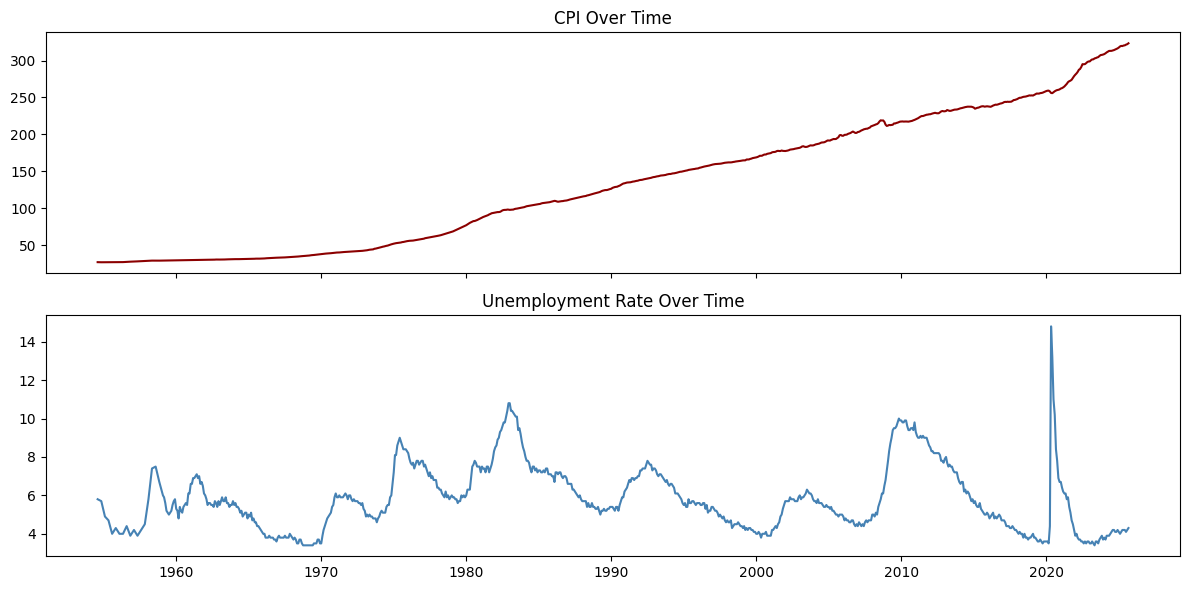

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(df.index, df['cpi'], color='darkred')
ax[0].set_title("CPI Over Time")

ax[1].plot(df.index, df['unemployment'], color='steelblue')
ax[1].set_title("Unemployment Rate Over Time")

plt.tight_layout()
plt.show()

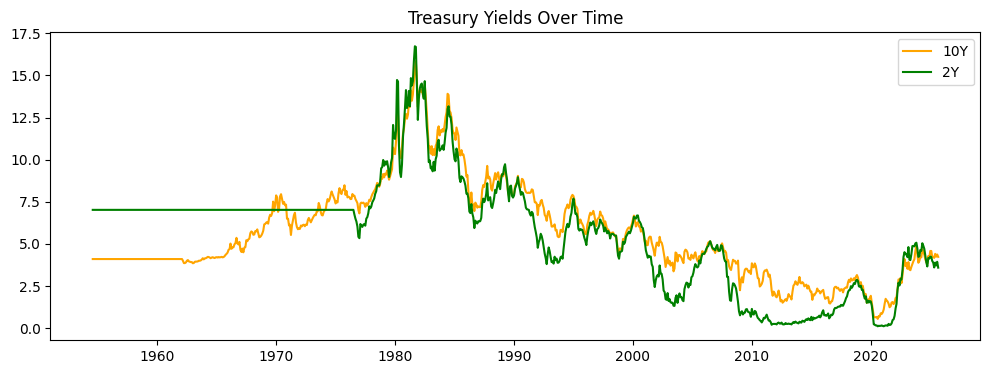

In [12]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['treasury_10y'], label="10Y", color="orange")
plt.plot(df.index, df['treasury_2y'], label="2Y", color="green")
plt.title("Treasury Yields Over Time")
plt.legend()
plt.show()

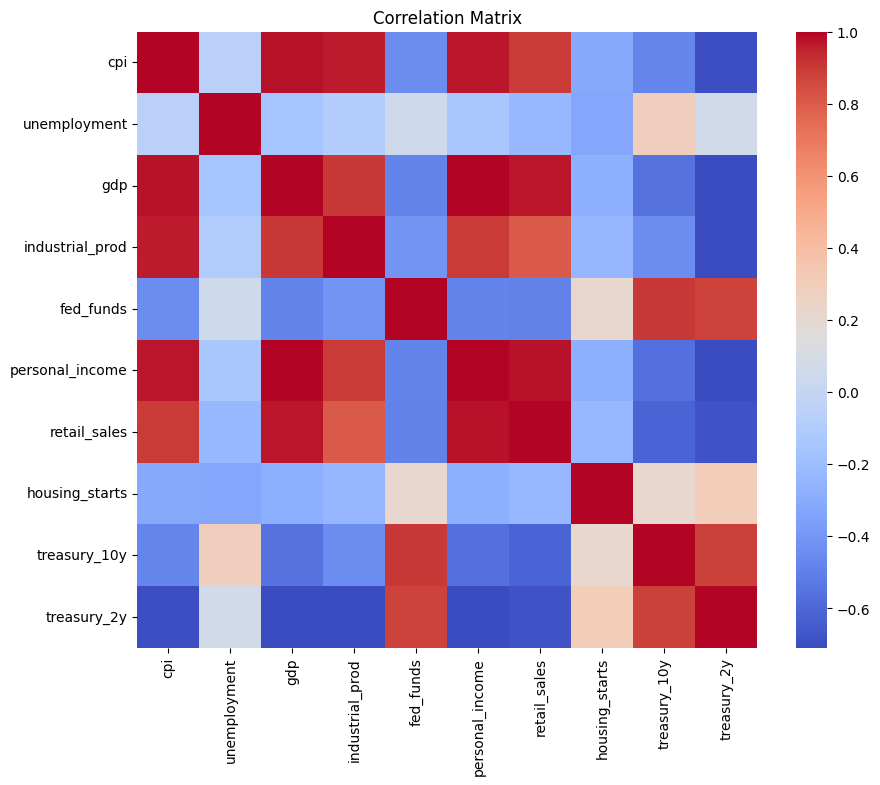

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

In [14]:
target = "treasury_10y"
features = df.drop(columns=["treasury_10y"])

X = features.values
y = df[target].values

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (818, 9)
Target vector shape: (818,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(X_train.shape, X_test.shape)

(654, 9) (164, 9)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("Baseline Linear Regression RMSE:", rmse)

Baseline Linear Regression RMSE: 4.494015530619281


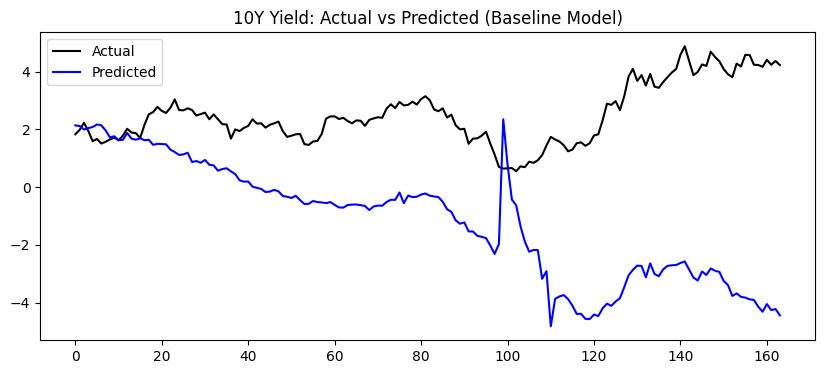

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test, label="Actual", color="black")
plt.plot(preds, label="Predicted", color="blue")
plt.legend()
plt.title("10Y Yield: Actual vs Predicted (Baseline)")
plt.show()

In [22]:
coef_series = pd.Series(model.coef_, index=features.columns)
coef_series.sort_values(ascending=False)

unemployment       0.527588
treasury_2y        0.522816
fed_funds          0.197231
industrial_prod    0.091768
gdp                0.000076
housing_starts     0.000014
retail_sales      -0.000014
personal_income   -0.000304
cpi               -0.001291
dtype: float64